# NSGD vs LSTM-PPO - Evaluation Comparison

Compares the two agents over the first 90 minutes of their evaluation runs using per-request logs.

**Files expected:**
- `logs/nsgd.../request_log.csv` - NSGD evaluation request log
- `logs/rl_eval/request_log.csv` - LSTM-PPO evaluation request log

Request logs do not contain Prometheus-only fields such as CPU and memory, so those sections report that the metric is unavailable from this data source.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
})

NSGD_DIR = 'logs/rl_eval'
LSTM_PPO_DIR = 'logs/rl_last_final_train_after_48_hours_eval'
OUT_DIR = 'logs/comparison'
os.makedirs(OUT_DIR, exist_ok=True)

WINDOW_MINUTES = 90
BUCKET_SECONDS = 30

COLOR_NSGD = '#2196F3'
COLOR_PPO = '#FF6F00'

# Load per-request logs instead of periodic samples.
nsgd_requests = pd.read_csv(f'{NSGD_DIR}/request_log.csv')
ppo_requests = pd.read_csv(f'{LSTM_PPO_DIR}/request_log.csv')

BOOL_COLUMNS = ['rejected', 'saturated_at_arrival', 'is_cold_start']

def normalize_requests(df):
    df = df.copy()
    for col in BOOL_COLUMNS:
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].astype(str).str.lower().isin(['true', '1', 'yes'])
            else:
                df[col] = df[col].astype(bool)
    start = df['timestamp'].min()
    df['seconds_from_start'] = df['timestamp'] - start
    df['minutes_from_start'] = df['seconds_from_start'] / 60
    return df[df['minutes_from_start'] <= WINDOW_MINUTES].reset_index(drop=True)

def aggregate_request_windows(df, bucket_seconds=BUCKET_SECONDS):
    df = normalize_requests(df)
    if df.empty:
        return df

    df['bucket'] = (df['seconds_from_start'] // bucket_seconds).astype(int)
    grouped = df.groupby('bucket', as_index=False)

    out = grouped.agg(
        seconds_from_start=('seconds_from_start', 'min'),
        timestamp=('timestamp', 'min'),
        requests=('timestamp', 'size'),
        rejected_requests=('rejected', 'sum'),
        nsgd_cost=('nsgd_cost', 'mean'),
        latency_seconds=('latency_seconds', 'mean'),
        p99_latency_seconds=('latency_seconds', lambda s: s.quantile(0.99)),
        ready_pods=('ready_pods', 'mean'),
        not_ready_pods=('not_ready_pods', 'mean'),
        idle_on=('idle_on', 'mean'),
        busy=('busy', 'mean'),
        init_reserved=('init_reserved', 'mean'),
        cold=('cold', 'mean'),
        cold_starts=('is_cold_start', 'sum'),
    )
    out['minutes_from_start'] = out['seconds_from_start'] / 60
    out['throughput'] = ((out['requests'] - out['rejected_requests']) / out['requests'] * 100).round(2)
    out['proxy_rejections'] = out['rejected_requests']
    out['avg_response_latency_ms'] = out['latency_seconds'] * 1000
    out['p99_response_latency_ms'] = out['p99_latency_seconds'] * 1000
    out['replicas'] = out['ready_pods']
    return out.reset_index(drop=True)

# `nsgd` and `ppo` are now windowed views derived from request_log.csv.
nsgd_req = normalize_requests(nsgd_requests)
ppo_req = normalize_requests(ppo_requests)
nsgd = aggregate_request_windows(nsgd_requests)
ppo = aggregate_request_windows(ppo_requests)

print(f'NSGD requests in first {WINDOW_MINUTES} min: {len(nsgd_req)}')
print(f'LSTM-PPO requests in first {WINDOW_MINUTES} min: {len(ppo_req)}')
print(f'NSGD request-window rows: {len(nsgd)}')
print(f'LSTM-PPO request-window rows: {len(ppo)}')


NSGD requests in first 90 min: 1264
LSTM-PPO requests in first 90 min: 1254
NSGD request-window rows: 173
LSTM-PPO request-window rows: 175


## Throughput

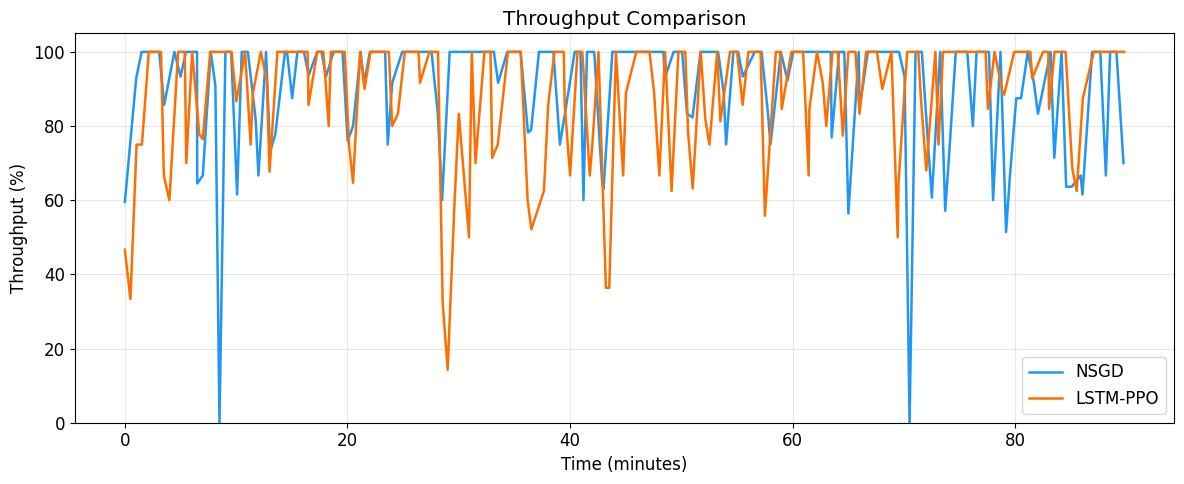

NSGD mean:     90.50%
LSTM-PPO mean: 88.46%


In [21]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['throughput'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['throughput'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Throughput (%)')
ax.set_title('Throughput Comparison')
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_throughput.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD mean:     {nsgd["throughput"].mean():.2f}%')
print(f'LSTM-PPO mean: {ppo["throughput"].mean():.2f}%')

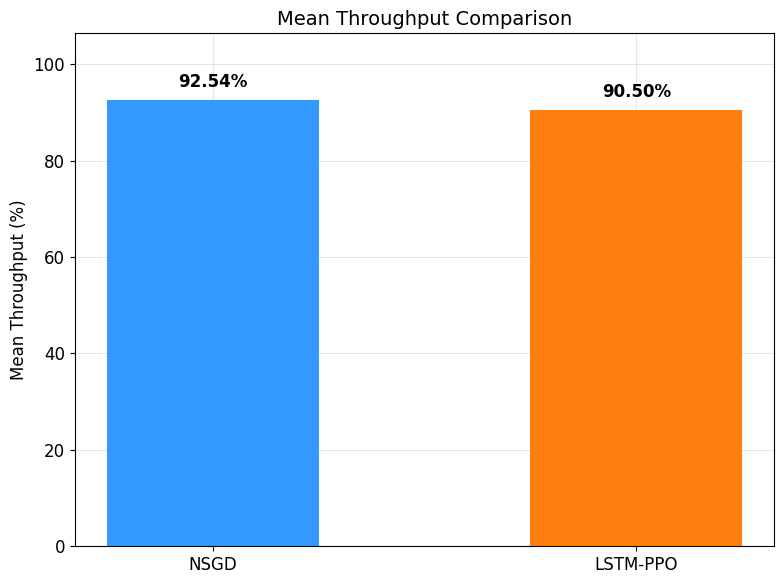

In [3]:
import matplotlib.pyplot as plt

# 1. Calculate the mean throughputs
nsgd_mean_throughput = nsgd["throughput"].mean()
ppo_mean_throughput = ppo["throughput"].mean()

# 2. Set up the data for the plot
models = ['NSGD', 'LSTM-PPO']
means = [nsgd_mean_throughput, ppo_mean_throughput]
colors = ['#3399FF', '#FF7F0E']  # Matching the requested blue and orange

# 3. Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(models, means, color=colors, width=0.5)

# 4. Apply formatting and labels
plt.title('Mean Throughput Comparison', fontsize=14)
plt.ylabel('Mean Throughput (%)', fontsize=12)

# Grid styling
plt.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
plt.gca().set_axisbelow(True)

# Give the y-axis a little extra room at the top so the text labels fit nicely
plt.ylim(0, max(means) * 1.15)

# 5. Add the exact percentage values on top of the bars
for bar in bars:
    yval = bar.get_height()
    # Adding the .2f% formatting inside the text label
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(means) * 0.02), 
             f"{yval:.2f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Display the plot
plt.tight_layout()
plt.show()

## Total Rejected Function Calls (cumulative)

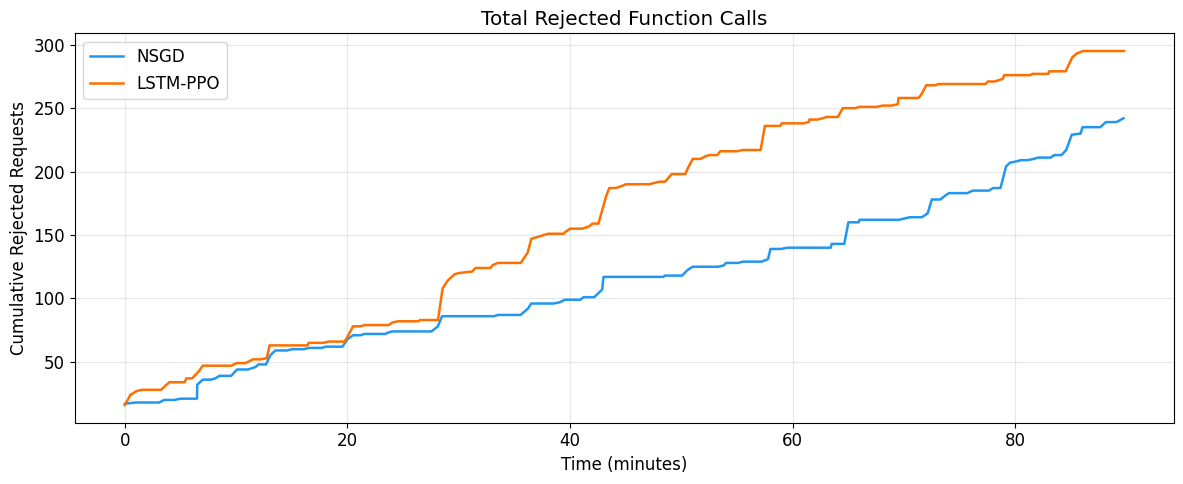

NSGD total rejections:     242
LSTM-PPO total rejections: 295


In [22]:
nsgd['cum_rejections'] = nsgd['proxy_rejections'].cumsum()
ppo['cum_rejections'] = ppo['proxy_rejections'].cumsum()

fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['cum_rejections'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['cum_rejections'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Cumulative Rejected Requests')
ax.set_title('Total Rejected Function Calls')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_rejections.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD total rejections:     {int(nsgd["cum_rejections"].iloc[-1])}')
print(f'LSTM-PPO total rejections: {int(ppo["cum_rejections"].iloc[-1])}')

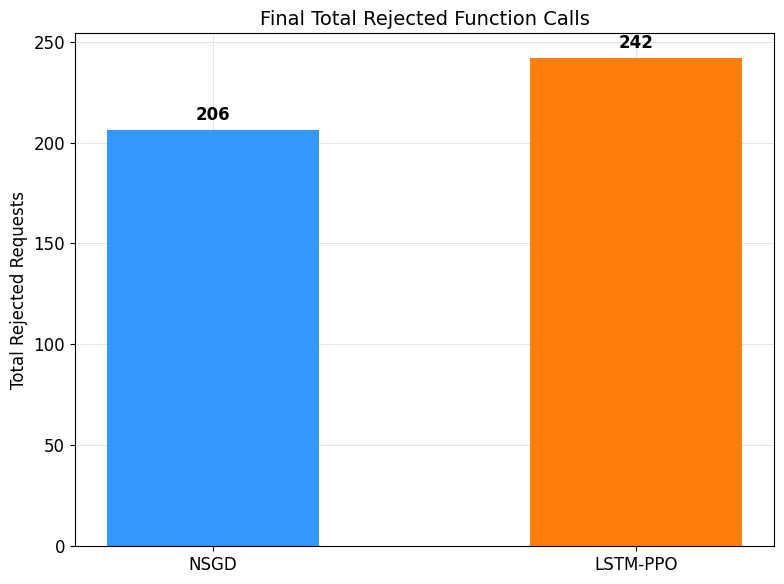

In [5]:
import matplotlib.pyplot as plt

# 1. Extract the final total from the end of the cumulative series
nsgd_final_total = nsgd['cum_rejections'].iloc[-1]
ppo_final_total = ppo['cum_rejections'].iloc[-1]

# 2. Set up the data for the plot
models = ['NSGD', 'LSTM-PPO']
totals = [nsgd_final_total, ppo_final_total]
colors = ['#3399FF', '#FF7F0E']  # Matching the requested blue and orange

# 3. Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(models, totals, color=colors, width=0.5)

# 4. Apply formatting and labels
plt.title('Final Total Rejected Function Calls', fontsize=14)
plt.ylabel('Total Rejected Requests', fontsize=12)

# Grid styling
plt.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
plt.gca().set_axisbelow(True)

# 5. Add the exact numerical values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, int(yval), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Display the plot
plt.tight_layout()
plt.show()

## NSGD Cost

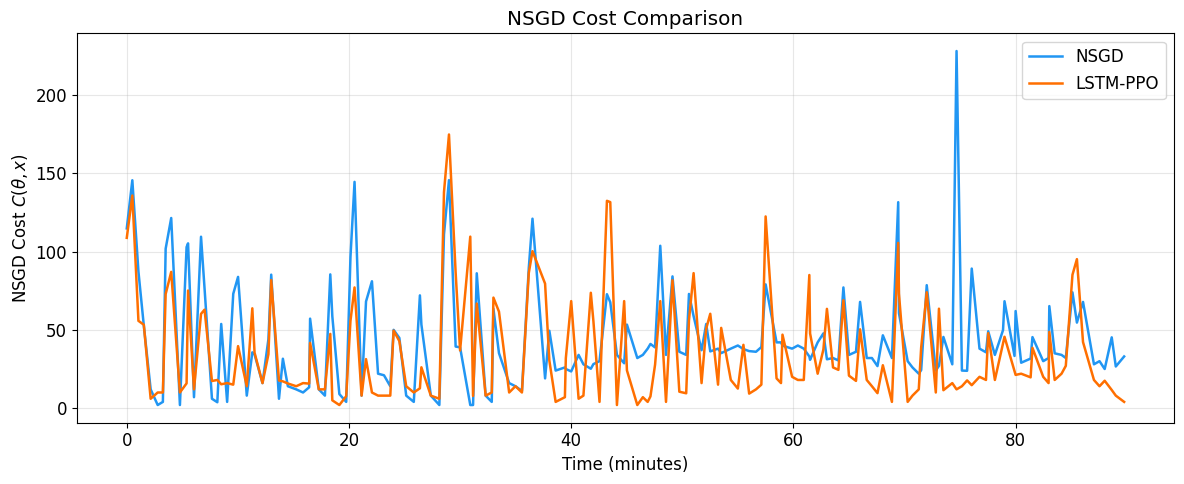

NSGD mean cost:     44.58
LSTM-PPO mean cost: 35.19


In [18]:
fig, ax = plt.subplots()
ax.plot(nsgd['minutes_from_start'], nsgd['nsgd_cost'],
        color=COLOR_NSGD, label='NSGD')
ax.plot(ppo['minutes_from_start'], ppo['nsgd_cost'],
        color=COLOR_PPO, label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('NSGD Cost $C(\\theta, x)$')
ax.set_title('NSGD Cost Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/comp_nsgd_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'NSGD mean cost:     {nsgd["nsgd_cost"].mean():.2f}')
print(f'LSTM-PPO mean cost: {ppo["nsgd_cost"].mean():.2f}')

## LSTM-PPO Reward

`request_log.csv` does not include `lstm_ppo_reward`, `avg_cpu`, or `avg_mem`. That reward is only available in `samples.csv` unless you recompute it with matching resource metrics.


In [7]:
print('LSTM-PPO reward is not available from request_log.csv.')
print('Use samples.csv for this plot, or add/recompute avg_cpu and avg_mem in the request log pipeline.')


LSTM-PPO reward is not available from request_log.csv.
Use samples.csv for this plot, or add/recompute avg_cpu and avg_mem in the request log pipeline.


## CPU Utilization

CPU utilization is not present in `request_log.csv`.


In [ ]:
print('CPU utilization is not available from request_log.csv.')
print('Use samples.csv or Kubernetes/Prometheus resource metrics for this plot.')


## Memory Utilization

Memory utilization is not present in `request_log.csv`.


In [ ]:
print('Memory utilization is not available from request_log.csv.')
print('Use samples.csv or Kubernetes/Prometheus resource metrics for this plot.')


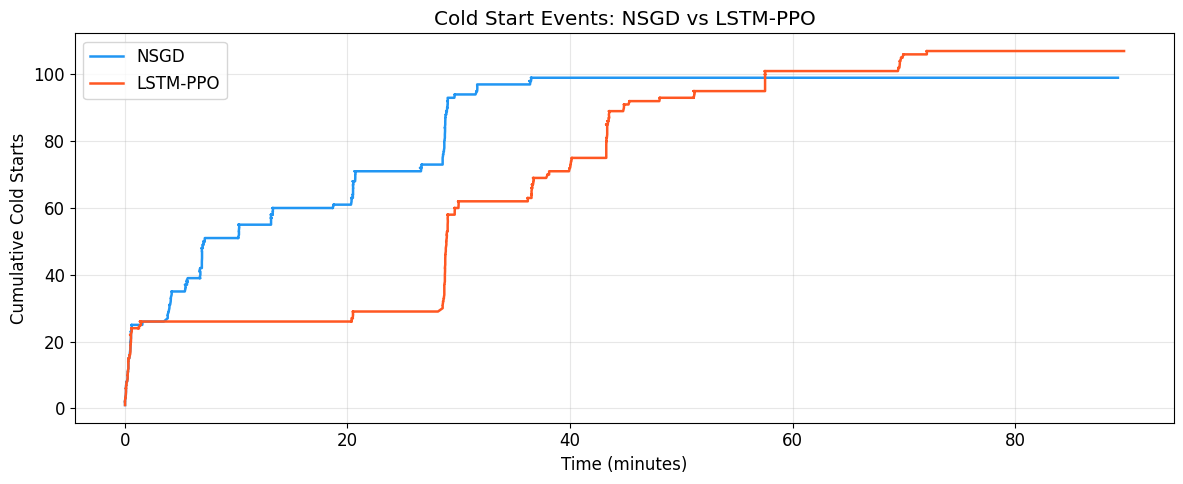

Duration: 89.8 minutes

NSGD:     1,253 requests, 99 cold starts (7.90%)
LSTM-PPO: 1,254 requests, 107 cold starts (8.53%)


In [19]:
# Cumulative cold start counts from the same request-log data loaded above.
max_minutes = min(nsgd_req['minutes_from_start'].max(), ppo_req['minutes_from_start'].max())
nsgd_cold = nsgd_req[nsgd_req['minutes_from_start'] <= max_minutes].copy()
ppo_cold = ppo_req[ppo_req['minutes_from_start'] <= max_minutes].copy()

nsgd_cold['cum_cold'] = nsgd_cold['is_cold_start'].astype(int).cumsum()
ppo_cold['cum_cold'] = ppo_cold['is_cold_start'].astype(int).cumsum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(nsgd_cold['minutes_from_start'], nsgd_cold['cum_cold'], color='#2196F3', label='NSGD')
ax.plot(ppo_cold['minutes_from_start'], ppo_cold['cum_cold'], color='#FF5722', label='LSTM-PPO')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Cumulative Cold Starts')
ax.set_title('Cold Start Events: NSGD vs LSTM-PPO')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cold_start_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Duration: {max_minutes:.1f} minutes')
print()
print(f'NSGD:     {len(nsgd_cold):,} requests, '
      f'{nsgd_cold["is_cold_start"].sum()} cold starts '
      f'({nsgd_cold["is_cold_start"].mean() * 100:.2f}%)')
print(f'LSTM-PPO: {len(ppo_cold):,} requests, '
      f'{ppo_cold["is_cold_start"].sum()} cold starts '
      f'({ppo_cold["is_cold_start"].mean() * 100:.2f}%)')


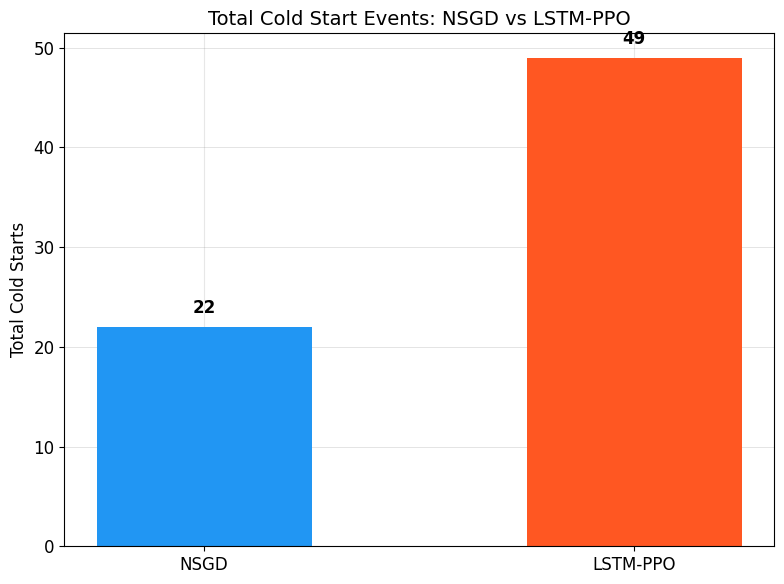

Duration: 90.0 minutes

NSGD:     1,263 requests, 22 cold starts (1.74%)
LSTM-PPO: 1,264 requests, 49 cold starts (3.88%)


In [9]:
# Total cold start bar chart from request_log.csv.
max_minutes = min(nsgd_req['minutes_from_start'].max(), ppo_req['minutes_from_start'].max())
nsgd_cold = nsgd_req[nsgd_req['minutes_from_start'] <= max_minutes].copy()
ppo_cold = ppo_req[ppo_req['minutes_from_start'] <= max_minutes].copy()

nsgd_total_cold = int(nsgd_cold['is_cold_start'].sum())
ppo_total_cold = int(ppo_cold['is_cold_start'].sum())

fig, ax = plt.subplots(figsize=(8, 6))
models = ['NSGD', 'LSTM-PPO']
totals = [nsgd_total_cold, ppo_total_cold]
colors = ['#2196F3', '#FF5722']

bars = ax.bar(models, totals, color=colors, width=0.5)
ax.set_ylabel('Total Cold Starts', fontsize=12)
ax.set_title('Total Cold Start Events: NSGD vs LSTM-PPO', fontsize=14)
ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

label_offset = max(totals) * 0.02 if max(totals) else 1
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + label_offset, int(yval),
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cold_start_total_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Duration: {max_minutes:.1f} minutes')
print()
print(f'NSGD:     {len(nsgd_cold):,} requests, '
      f'{nsgd_total_cold} cold starts '
      f'({nsgd_cold["is_cold_start"].mean() * 100:.2f}%)')
print(f'LSTM-PPO: {len(ppo_cold):,} requests, '
      f'{ppo_total_cold} cold starts '
      f'({ppo_cold["is_cold_start"].mean() * 100:.2f}%)')


In [ ]:
# Latency summary from request_log.csv.
print('Request latency from request_log.csv')
print()
print('NSGD:')
print(f'  mean:   {nsgd_req["latency_seconds"].mean() * 1000:.1f} ms')
print(f'  median: {nsgd_req["latency_seconds"].median() * 1000:.1f} ms')
print(f'  p99:    {nsgd_req["latency_seconds"].quantile(0.99) * 1000:.1f} ms')
print()
print('LSTM-PPO:')
print(f'  mean:   {ppo_req["latency_seconds"].mean() * 1000:.1f} ms')
print(f'  median: {ppo_req["latency_seconds"].median() * 1000:.1f} ms')
print(f'  p99:    {ppo_req["latency_seconds"].quantile(0.99) * 1000:.1f} ms')
